### Import Libraries

In [10]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

import imblearn

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, 
                            roc_auc_score, confusion_matrix, classification_report, precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt


### Add Synthetic Noise

In [3]:
file_path = r"C:\Users\HP\Desktop\Infotact Internship\week2_fused_dataset.csv"

In [4]:
df = pd.read_csv(file_path)
df.shape

(10000, 39)

In [5]:
target = 'Machine failure'
df[target].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [6]:
X = df.drop(columns=[target])
# Remove identifier columns
X = X.drop(columns=["Product ID", "Timestamp"])

import re

X.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', str(col))
    for col in X.columns
]

X.shape

(10000, 36)

In [8]:
y = df[target]

### Stratified 5-Fold Cross Validation

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [12]:
skf.split(X, y)

<generator object _BaseKFold.split at 0x00000110C1AE5480>

### Lists to Store Metrics

In [13]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = []

### Training Loop

In [14]:
fold = 1

for train_index, test_index in skf.split(X, y):
    print("="*60)
    print(f"Fold {fold}")

    x_train, x_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    smote = SMOTE(random_state=42)

    x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

    print("Original Training shape:", y_train.value_counts().to_dict())
    print("Resampled Training shape:", y_train_smote.value_counts().to_dict())

    # modelling
    model = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42)

    model.fit(x_train_smote, y_train_smote)

    y_pred = model.predict(x_test)

    y_prob = model.predict_proba(x_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    auc_scores.append(auc)

    print("\n classification_report \n")
    print(classification_report(y_test, y_pred))
    print("\n confusion_matrix \n")
    print(confusion_matrix(y_test, y_pred))
    print(f"AUC : {auc:.4f}")

    fold += 1


Fold 1
Original Training shape: {0: 7728, 1: 272}
Resampled Training shape: {0: 7728, 1: 7728}
[LightGBM] [Info] Number of positive: 7728, number of negative: 7728
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6994
[LightGBM] [Info] Number of data points in the train set: 15456, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

 classification_report 

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1933
           1       0.82      0.97      0.89        67

    accuracy                           0.99      2000
   macro avg       0.91      0.98      0.94      2000
weighted avg       0.99      0.99      0.99      2000


 confusion_matrix 

[[1919   14]
 [   2   65]]
AUC : 0.9921
Fold 2
Original Training shape: {0: 7729, 1: 271}
Resa

### Average Results

In [15]:
print("="*70)

print("Average Accuracy :", np.mean(accuracy_scores))
print("Average Precision :", np.mean(precision_scores))
print("Average Recall :", np.mean(recall_scores))
print("Average F1 Score :", np.mean(f1_scores))
print("Average ROC-AUC :", np.mean(auc_scores))

Average Accuracy : 0.9936999999999999
Average Precision : 0.8623788798335357
Average Recall : 0.9705004389815628
Average F1 Score : 0.9129253819431611
Average ROC-AUC : 0.9894565602095365


### Add Synthetic Noise

In [16]:
def add_noise(X, noise_level=0.05):

    """Add gaussian noise to only numeric features"""
    X_noisy = X.copy()
    numeric_cols = X_noisy.select_dtypes(include=[np.number]).columns

    noise = np.random.normal(loc=0, scale=noise_level, size=X_noisy[numeric_cols].shape)

    X_noisy[numeric_cols] = X_noisy[numeric_cols] + noise

    return X_noisy


### Predict on Noisy Data


In [17]:
X_test_noisy = add_noise(x_test, noise_level=0.05)

y_prob_noisy = model.predict_proba(X_test_noisy)[:,1]

### Evaluate Robustness

In [18]:
noise_levels = [0,0.01,0.03,0.05,0.1]

for noise in noise_levels:

    X_noise = add_noise(x_test, noise)

    pred = model.predict(X_noise)

    acc = accuracy_score(y_test,pred)

    print(f"Noise = {noise:.2f}")

    print("Accuracy:",acc)

    print("-------------------------")

Noise = 0.00
Accuracy: 0.9955
-------------------------
Noise = 0.01
Accuracy: 0.189
-------------------------
Noise = 0.03
Accuracy: 0.1995
-------------------------
Noise = 0.05
Accuracy: 0.1955
-------------------------
Noise = 0.10
Accuracy: 0.2055
-------------------------


### Precision-Recall Curve

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_noisy)

ap = average_precision_score(y_test, y_prob_noisy)

### Plot Precision-Recall Curve

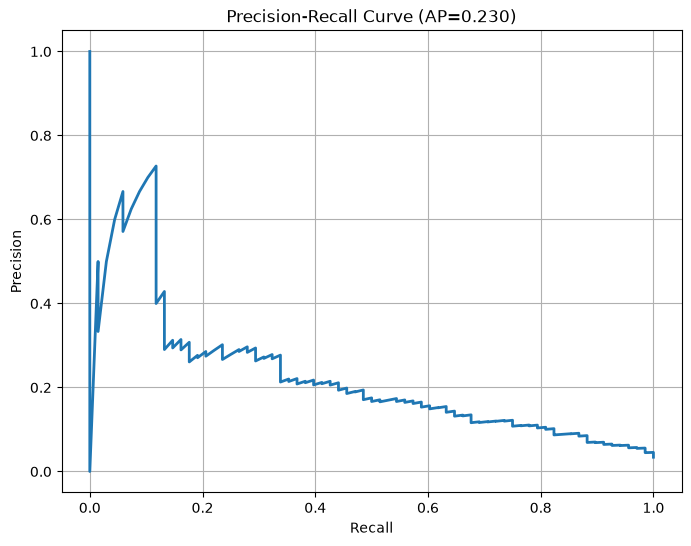

In [21]:
plt.figure(figsize=(8,6))

plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(f"Precision-Recall Curve (AP={ap:.3f})")

plt.grid(True)

plt.show()

### Threshold Tuning

In [22]:
thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

In [23]:
for threshold in thresholds_to_test:

    prediction = (y_prob_noisy >= threshold).astype(int)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    print("="*50)

    print("Threshold:",threshold)

    print("Precision:",precision)

    print("Recall:",recall)

    print("F1:",f1)

Threshold: 0.3
Precision: 0.03955788248981966
Recall: 1.0
F1: 0.07610520425293789
Threshold: 0.4
Precision: 0.04045211183819155
Recall: 1.0
F1: 0.07775871926815323
Threshold: 0.5
Precision: 0.041112454655380895
Recall: 1.0
F1: 0.07897793263646923
Threshold: 0.6
Precision: 0.041692213366033105
Recall: 1.0
F1: 0.08004708652148322
Threshold: 0.7
Precision: 0.04252657911194497
Recall: 1.0
F1: 0.08158368326334733
Threshold: 0.8
Precision: 0.043339706819630335
Recall: 1.0
F1: 0.08307880268784362


### Best Threshold

In [24]:
best_threshold = 0
best_f1 = 0

for threshold in np.arange(0.1,0.95,0.01):

    prediction = (y_prob_noisy >= threshold).astype(int)
    score = f1_score(y_test, prediction)

    if score > best_f1:

        best_f1 = score
        best_threshold = threshold

print(best_threshold)

print(best_f1)

0.9199999999999996
0.08690095846645367


### Final confusion Matrix

In [25]:
prediction = (y_prob_noisy >= best_threshold).astype(int)

print(confusion_matrix(y_test, prediction))

print(classification_report(y_test, prediction))

[[ 503 1429]
 [   0   68]]
              precision    recall  f1-score   support

           0       1.00      0.26      0.41      1932
           1       0.05      1.00      0.09        68

    accuracy                           0.29      2000
   macro avg       0.52      0.63      0.25      2000
weighted avg       0.97      0.29      0.40      2000

